In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


In [11]:
df = pd.read_csv('../data/telco_churn.csv')
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 7043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0])
print(f"\nTipos de datos únicos: {df.dtypes.unique()}")

Valores nulos por columna:
Series([], dtype: int64)

Tipos de datos únicos: [dtype('O') dtype('int64') dtype('float64')]


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Clientes que NO hacen churn: 73.5%
Clientes que SÍ hacen churn: 26.5%


/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/324567376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71','#e74c3c'])


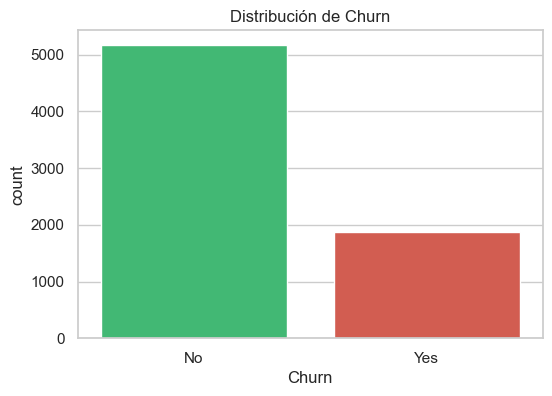

In [14]:
churn_counts = df['Churn'].value_counts()
porcentaje = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nClientes que NO hacen churn: {porcentaje['No']:.1f}%")
print(f"Clientes que SÍ hacen churn: {porcentaje['Yes']:.1f}%")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71','#e74c3c'])
plt.title('Distribución de Churn')
plt.savefig('../data/churn_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/4153488989.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette=['#2ecc71','#e74c3c'], ax=ax)
/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/4153488989.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette=['#2ecc71','#e74c3c'], ax=ax)
/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/4153488989.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palett

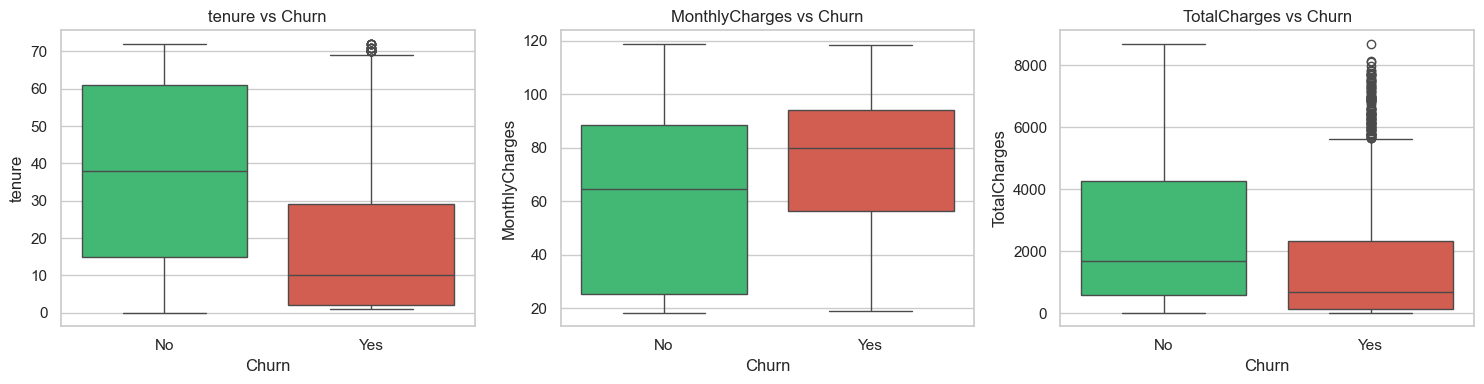

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, palette=['#2ecc71','#e74c3c'], ax=ax)
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.savefig('../data/numericas_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/3970285680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x=col, y='churn_rate', palette='Reds_r', ax=ax)
/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/3970285680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x=col, y='churn_rate', palette='Reds_r', ax=ax)
/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_28548/3970285680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x=col, y='churn_

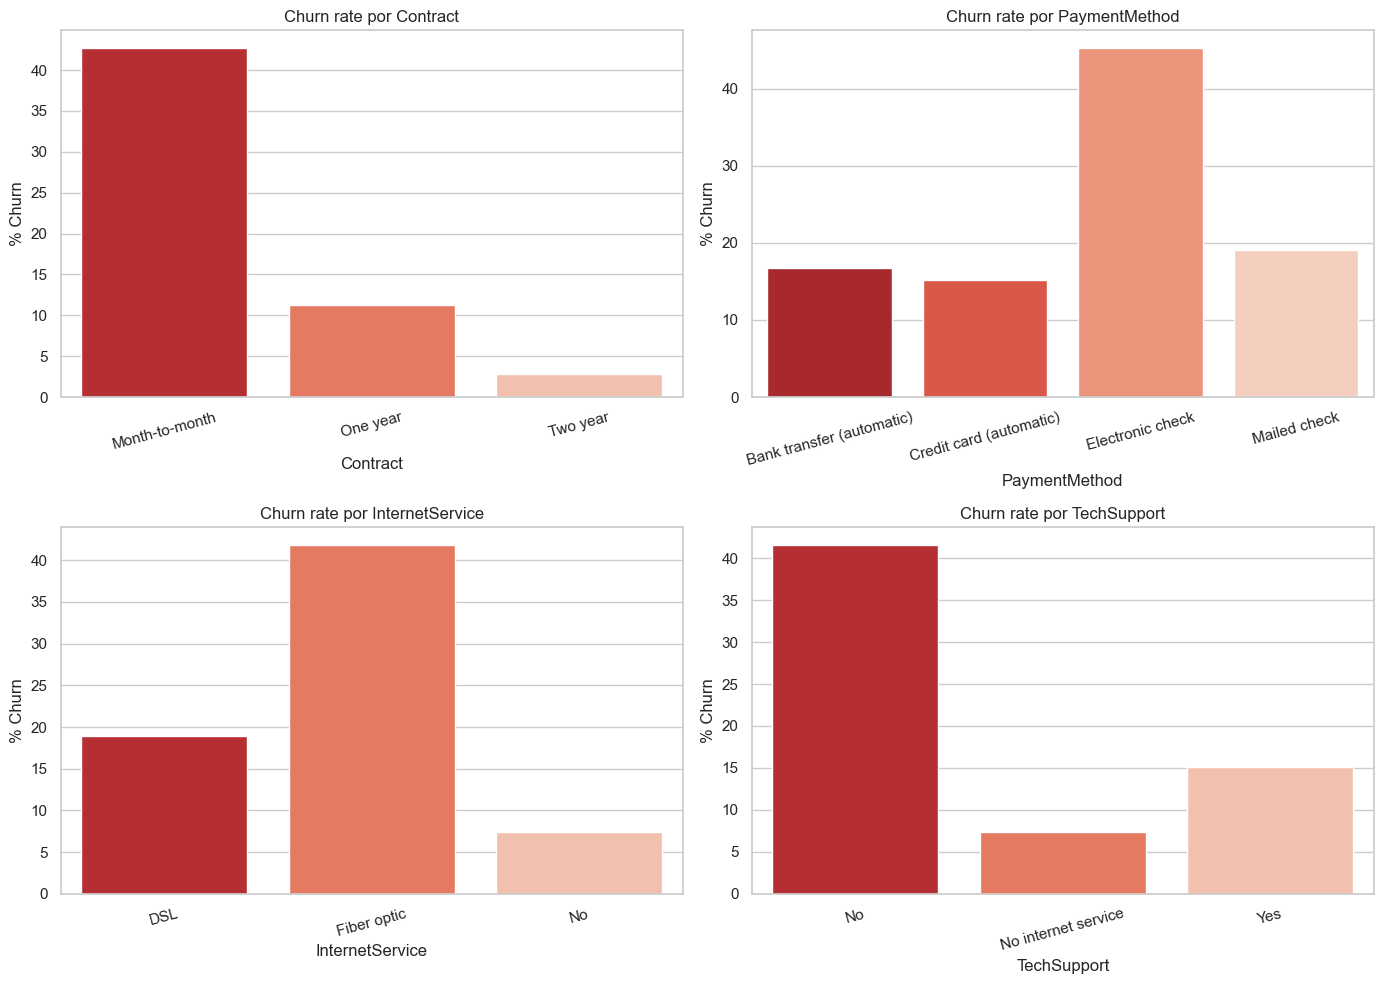

In [16]:
categoricas = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categoricas):
    churn_pct = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_pct.columns = [col, 'churn_rate']
    sns.barplot(data=churn_pct, x=col, y='churn_rate', palette='Reds_r', ax=ax)
    ax.set_title(f'Churn rate por {col}')
    ax.set_ylabel('% Churn')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/categoricas_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print("=== HALLAZGOS PRINCIPALES ===\n")
print(f"1. Desbalance de clases: solo {porcentaje['Yes']:.1f}% hace churn → usaremos SMOTE en el modelo")
print(f"2. TotalCharges tiene {df['TotalCharges'].isnull().sum()} valores nulos → los imputaremos")
print(f"3. Clientes con contrato mes-a-mes tienen mayor churn rate")
print(f"4. A mayor antigüedad (tenure), menor probabilidad de churn")
print(f"\nDataset listo para la Semana 2: Feature Engineering + Modelo XGBoost ✅")

=== HALLAZGOS PRINCIPALES ===

1. Desbalance de clases: solo 26.5% hace churn → usaremos SMOTE en el modelo
2. TotalCharges tiene 11 valores nulos → los imputaremos
3. Clientes con contrato mes-a-mes tienen mayor churn rate
4. A mayor antigüedad (tenure), menor probabilidad de churn

Dataset listo para la Semana 2: Feature Engineering + Modelo XGBoost ✅
